# Лабораторная работа: Neural Collaborative Filtering (MovieLens 20M)
**Цель:** проектирование и реализация нейросетевой модели для генерации персональных рекомендаций на основе датасета **MovieLens 20M**.

In [ ]:
%pip install numpy pandas torch matplotlib scikit-learn

In [2]:
import os
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Загрузка данных


In [3]:
# ===== ЛОКАЛЬНЫЙ ПУТЬ =====
DATA_DIR = r"C:\Users\Leoni\OneDrive\Documents\Универ\8 semestr\data"

ratings_path = os.path.join(DATA_DIR, "rating.csv")
movies_path  = os.path.join(DATA_DIR, "movie.csv")

if not os.path.exists(ratings_path):
    raise FileNotFoundError(f"ratings.csv не найден по пути: {ratings_path}")

ratings = pd.read_csv(ratings_path)
movies  = pd.read_csv(movies_path)

print("Ratings:", ratings.shape)
print("Movies:", movies.shape)
ratings.head()


Ratings: (20000263, 4)
Movies: (27278, 3)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


## Предобработка данных

In [4]:
min_user_ratings = 20
min_item_ratings = 20
max_interactions = 1_000_000

ratings_clean = ratings.drop_duplicates()

user_cnt = ratings_clean["userId"].value_counts()
item_cnt = ratings_clean["movieId"].value_counts()

ratings_clean = ratings_clean[
    ratings_clean["userId"].isin(user_cnt[user_cnt >= min_user_ratings].index) &
    ratings_clean["movieId"].isin(item_cnt[item_cnt >= min_item_ratings].index)
].copy()

if len(ratings_clean) > max_interactions:
    ratings_clean = ratings_clean.sample(n=max_interactions, random_state=42).copy()

user2idx = {u: i for i, u in enumerate(ratings_clean["userId"].unique())}
item2idx = {m: i for i, m in enumerate(ratings_clean["movieId"].unique())}

ratings_clean["user_idx"] = ratings_clean["userId"].map(user2idx).astype(np.int64)
ratings_clean["item_idx"] = ratings_clean["movieId"].map(item2idx).astype(np.int64)

num_users = ratings_clean["user_idx"].nunique()
num_items = ratings_clean["item_idx"].nunique()

print("Interactions:", len(ratings_clean))
print("Users:", num_users, "Items:", num_items)


Interactions: 1000000
Users: 125696 Items: 12516


## Time-aware split

In [5]:
ratings_sorted = ratings_clean.sort_values(["user_idx", "timestamp"])

test_idx = ratings_sorted.groupby("user_idx").tail(1).index
test_df = ratings_sorted.loc[test_idx].copy()
train_df = ratings_sorted.drop(index=test_idx).copy()

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.ratings = torch.tensor(df["rating"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_loader = DataLoader(RatingsDataset(train_df), batch_size=2048, shuffle=True)
test_loader  = DataLoader(RatingsDataset(test_df), batch_size=4096, shuffle=False)

print("Train:", len(train_df), "Test:", len(test_df))


Train: 874304 Test: 125696


## Модель NeuralCF

In [6]:
class NeuralCF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=64, hidden=(128, 64), dropout=0.1):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        layers = []
        in_dim = emb_dim * 2
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.mlp = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, u, i):
        ue = self.user_emb(u)
        ie = self.item_emb(i)
        x = torch.cat([ue, ie], dim=1)
        return self.mlp(x).squeeze(-1)

model = NeuralCF(num_users, num_items).to(device)
model


NeuralCF(
  (user_emb): Embedding(125696, 64)
  (item_emb): Embedding(12516, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

По структуре модели видно, что каждый пользователь и фильм кодируются в 64-мерные эмбеддинги. После объединения признаков используется двухслойный перцептрон (128→64→1), что позволяет модели учитывать нелинейные взаимодействия между пользователем и объектом.


## Обучение

In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-6)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    preds_all = []
    target_all = []

    with torch.set_grad_enabled(is_train):
        for u, it, r in loader:
            u, it, r = u.to(device), it.to(device), r.to(device)
            pred = model(u, it)
            loss = criterion(pred, r)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(loss.item())

            if not is_train:
                preds_all.append(pred.detach().cpu().numpy())
                target_all.append(r.detach().cpu().numpy())

    mean_loss = float(np.mean(losses))

    if is_train:
        return mean_loss, None

    preds = np.concatenate(preds_all)
    target = np.concatenate(target_all)

    mse = mean_squared_error(target, preds)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(target, preds)

    return mean_loss, {"mse": mse, "rmse": rmse, "mae": mae}

history = {"train_mse": [], "test_mse": []}

for epoch in range(1, 6):
    train_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
    test_loss, metrics = run_epoch(model, test_loader, criterion)

    history["train_mse"].append(train_loss)
    history["test_mse"].append(test_loss)

    print(f"Epoch {epoch} | Train MSE: {train_loss:.4f} | Test MSE: {test_loss:.4f} | RMSE: {metrics['rmse']:.4f}")


Epoch 1 | Train MSE: 1.4604 | Test MSE: 0.9407 | RMSE: 0.9689
Epoch 2 | Train MSE: 0.7962 | Test MSE: 0.9402 | RMSE: 0.9685
Epoch 3 | Train MSE: 0.7376 | Test MSE: 0.9398 | RMSE: 0.9683
Epoch 4 | Train MSE: 0.7014 | Test MSE: 0.9715 | RMSE: 0.9846
Epoch 5 | Train MSE: 0.6725 | Test MSE: 0.9674 | RMSE: 0.9826


## Графики обучения
Графики помогают увидеть динамику оптимизации и признаки переобучения: если Train MSE продолжает падать, а Test MSE растёт — модель начинает переобучаться.

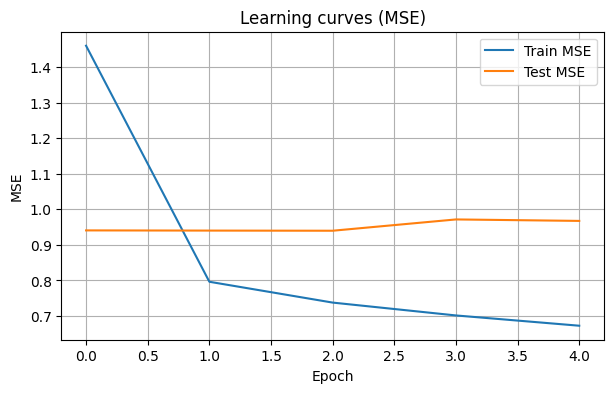

In [8]:
# Графики MSE по эпохам
plt.figure(figsize=(7,4))
plt.plot(history["train_mse"], label="Train MSE")
plt.plot(history["test_mse"], label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Learning curves (MSE)")
plt.legend()
plt.grid(True)
plt.show()


Модель переобучается после 2 эпох, так как train MSE падает, а test MSE начинает расти. Поэтому обучение следует останавливать раньше.


## Генерация Top-N рекомендаций
Предсказываем рейтинги для всех фильмов, которые пользователь **ещё не оценивал** в train, и выбираем лучшие.

In [ ]:
idx2item = {v: k for k, v in item2idx.items()}
movie_title = movies.set_index("movieId")["title"].to_dict()

def recommend(model, user_idx, n=10):
    seen = set(train_df.loc[train_df["user_idx"] == user_idx, "item_idx"].values)
    all_items = torch.arange(num_items, device=device)
    u_tensor = torch.full((num_items,), user_idx, dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        scores = model(u_tensor, all_items).detach().cpu().numpy()

    if len(seen) > 0:
        scores[list(seen)] = -1e9  # маскирование просмотренных

    top = np.argsort(scores)[-n:][::-1]
    return pd.DataFrame([{
        "title": movie_title.get(idx2item[i], "Unknown"),
        "score": float(scores[i])
    } for i in top])

# пример: рекомендации для пользователя 256
recommend(model, 256, n=10)


,title,score
0,Kamikaze Girls (Shimotsuma monogatari) (2004),4.526046
1,Violet & Daisy (2011),4.511270
2,12 (2007),4.373125
3,"Swedish Love Story, A (Kärlekshistoria, En) (1...",4.327618
4,"Shawshank Redemption, The (1994)",4.293513
5,"Bad Sleep Well, The (Warui yatsu hodo yoku nem...",4.273461
6,"Sorrow and the Pity, The (Le chagrin et la pit...",4.246098
7,"Wind, The (1928)",4.237943
8,Bright Future (Akarui mirai) (2003),4.229842
9,"Decalogue, The (Dekalog) (1989)",4.222234


## Метрики ранжирования: Precision k и Recall k (явная обратная связь)
Почему это важно: **RMSE/MSE** оценивают точность предсказания рейтинга, а **Precision k/Recall k** оценивают качество **топ-рекомендаций**.

Простой вариант для нашего time-aware split (1 тестовый фильм на пользователя):
- считаем тестовый фильм релевантным, если его рейтинг ≥ `relevance_threshold`
- проверяем, попал ли он в Top-k (среди неоценённых в train)

In [ ]:
def precision_recall_at_k_sampled(
    model,
    train_df,
    test_df,
    num_items,
    k=10,
    relevance_threshold=4.0,
    num_negatives=200,      # 100-500 обычно ок
    max_users=5000,         # чтобы точно быстро считалось
    seed=42,
):

    rng = np.random.default_rng(seed)
    model.eval()

    # seen items in train per user
    seen_by_user = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    # one test record per user (time-aware split)
    test_map = test_df.set_index("user_idx")[["item_idx", "rating"]].to_dict(orient="index")
    users = list(test_map.keys())

    # ограничим пользователей (чтобы было быстро и стабильно)
    if max_users is not None and len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()

    precisions = []
    recalls = []
    covered_users = 0

    with torch.no_grad():
        for u in users:
            test_item = int(test_map[u]["item_idx"])
            test_rating = float(test_map[u]["rating"])

            # релевантность (явная обратная связь)
            if test_rating < relevance_threshold:
                continue

            covered_users += 1
            seen = seen_by_user.get(u, set())

            # --- выбираем кандидатов: test_item + negatives ---
            candidates = [test_item]
            # быстрый негативный семплинг
            while len(candidates) < (1 + num_negatives):
                x = int(rng.integers(0, num_items))
                if (x not in seen) and (x != test_item):
                    candidates.append(x)

            candidates = np.array(candidates, dtype=np.int64)

            # --- скоринг кандидатов батчем ---
            u_tensor = torch.full((len(candidates),), u, dtype=torch.long, device=device)
            it_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

            scores = model(u_tensor, it_tensor).detach().cpu().numpy()

            # top-k среди кандидатов
            topk_idx = np.argpartition(scores, -k)[-k:]
            topk_idx = topk_idx[np.argsort(scores[topk_idx])[::-1]]

            topk_items = set(candidates[topk_idx].tolist())
            hit = 1 if test_item in topk_items else 0

            precisions.append(hit / k)
            recalls.append(hit / 1)

    precision = float(np.mean(precisions)) if precisions else 0.0
    recall = float(np.mean(recalls)) if recalls else 0.0
    return precision, recall, covered_users


# Пример запуска
p10, r10, n_users = precision_recall_at_k_sampled(
    model,
    train_df,
    test_df,
    num_items=num_items,
    k=10,
    relevance_threshold=4.0,
    num_negatives=200,
    max_users=5000,
    seed=42
)

print(f"Users with relevant test item (rating>=4.0): {n_users}")
print(f"Precision@10 (sampled): {p10:.6f}")
print(f"Recall@10 (sampled):    {r10:.6f}")

Users with relevant test item (rating>=4.0): 2720
Precision@10 (sampled): 0.018051
Recall@10 (sampled):    0.180515


## Выводы по работе

1. **NeuralCF** (эмбеддинги пользователя и фильма + MLP) позволяет обучать модель, которая предсказывает рейтинг и формирует Top-N рекомендации.
2. **Time-aware split** делает оценку более реалистичной: тест — это «будущая» оценка пользователя.
3. **Графики обучения** помогают диагностировать переобучение и подобрать число эпох/регуляризацию.
4. **Precision@k/Recall@k** дают оценку качества именно ранжирования (Top-k), что ближе к практической задаче рекомендаций.

### Пути улучшения
- Добавить **bias** (смещения) пользователей/фильмов
- Заменить MSE на **Huber loss**
- Перейти к **implicit feedback** (BCE/BPR), где цель — предсказать факт взаимодействия
- Добавить отрицательное семплирование и более корректную offline-оценку


## Метрики ранжирования (ускоренная оценка)
Наивная реализация может считаться **очень долго**, потому что для каждого пользователя оценивались **все фильмы** (U×I предсказаний). Ниже — быстрый подход **sampled evaluation**:

- для каждого пользователя берём **1 тестовый фильм**
- добавляем `num_negatives` случайных *негативных* кандидатов (которые пользователь не видел в train)
- проверяем, попал ли тестовый фильм в Top-k среди кандидатов

Этот подход широко используется для офлайн-оценки NCF/implicit-рекомендаций.

In [11]:
import numpy as np
import torch

def precision_recall_at_k_sampled(
    model,
    train_df,
    test_df,
    num_items,
    k=10,
    relevance_threshold=4.0,
    num_negatives=200,
    max_users=5000,
    seed=42,
):
    rng = np.random.default_rng(seed)
    model.eval()

    seen_by_user = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()
    test_map = test_df.set_index("user_idx")[["item_idx", "rating"]].to_dict(orient="index")
    users = list(test_map.keys())

    if max_users is not None and len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()

    precisions, recalls = [], []
    covered_users = 0

    with torch.no_grad():
        for u in users:
            test_item = int(test_map[u]["item_idx"])
            test_rating = float(test_map[u]["rating"])

            if test_rating < relevance_threshold:
                continue

            covered_users += 1
            seen = seen_by_user.get(u, set())

            candidates = [test_item]
            while len(candidates) < (1 + num_negatives):
                x = int(rng.integers(0, num_items))
                if (x not in seen) and (x != test_item):
                    candidates.append(x)

            candidates = np.array(candidates, dtype=np.int64)

            u_tensor = torch.full((len(candidates),), u, dtype=torch.long, device=device)
            it_tensor = torch.tensor(candidates, dtype=torch.long, device=device)
            scores = model(u_tensor, it_tensor).detach().cpu().numpy()

            topk_idx = np.argpartition(scores, -k)[-k:]
            topk_idx = topk_idx[np.argsort(scores[topk_idx])[::-1]]
            topk_items = set(candidates[topk_idx].tolist())

            hit = 1 if test_item in topk_items else 0
            precisions.append(hit / k)
            recalls.append(hit / 1)

    precision = float(np.mean(precisions)) if precisions else 0.0
    recall = float(np.mean(recalls)) if recalls else 0.0
    return precision, recall, covered_users

p10, r10, n_users = precision_recall_at_k_sampled(
    model, train_df, test_df,
    num_items=num_items,
    k=10,
    relevance_threshold=4.0,
    num_negatives=200,
    max_users=5000,
    seed=42
)

print(f"Users with relevant test item (rating>=4.0): {n_users}")
print(f"Precision@10 (sampled): {p10:.6f}")
print(f"Recall@10 (sampled):    {r10:.6f}")


Users with relevant test item (rating>=4.0): 2720
Precision@10 (sampled): 0.018051
Recall@10 (sampled):    0.180515


## Пример рекомендаций для выбранного пользователя
Ниже выводим:
- историю пользователя (несколько последних взаимодействий в train)
- **Top-N рекомендации**

По этим данным видно, что рекомендации зависят от пользовательской истории: модель старается предлагать фильмы, которые по эмбеддингам «похожи» на те, что уже нравились пользователю.

In [12]:
def show_user_profile_and_recs(user_idx=0, n_history=10, n_recs=10):
    hist = (train_df[train_df["user_idx"] == user_idx]
            .sort_values("timestamp", ascending=False)
            .head(n_history)
            .copy())
    hist["title"] = hist["item_idx"].map(lambda i: movie_title.get(idx2item[i], "Unknown"))
    print("=== User history (train, last interactions) ===")
    display(hist[["title", "rating", "timestamp"]])

    print("\n=== Top-N recommendations ===")
    display(recommend(model, user_idx, n=n_recs))

USER_ID = 256  # поменяй на нужного
show_user_profile_and_recs(USER_ID, n_history=10, n_recs=10)


=== User history (train, last interactions) ===


,title,rating,timestamp
11963894,Bedazzled (2000),3.5,2005-04-02 12:44:50
11963904,Moulin Rouge (2001),3.0,2005-04-02 12:44:17
11963852,Ghostbusters (a.k.a. Ghost Busters) (1984),4.0,2005-03-25 01:22:44
11963773,Star Wars: Episode VI - Return of the Jedi (1983),3.5,2005-03-25 01:21:13
11963844,"Matrix, The (1999)",4.0,2005-03-24 09:10:55
11963827,Blade (1998),2.5,2005-03-24 09:05:30
11963725,Speed (1994),3.5,2005-03-24 09:03:27



=== Top-N recommendations ===


,title,score
0,Kamikaze Girls (Shimotsuma monogatari) (2004),4.675338
1,Violet & Daisy (2011),4.660563
2,12 (2007),4.522417
3,"Swedish Love Story, A (Kärlekshistoria, En) (1...",4.497816
4,"Bad Sleep Well, The (Warui yatsu hodo yoku nem...",4.458462
5,"Shawshank Redemption, The (1994)",4.442806
6,"Sorrow and the Pity, The (Le chagrin et la pit...",4.399979
7,"Wind, The (1928)",4.387236
8,Bright Future (Akarui mirai) (2003),4.379135
9,"Best of Youth, The (La meglio gioventù) (2003)",4.373446


## Пути улучшения: реализации
Ниже приведены реализации улучшений из выводов. Их можно запускать по очереди и сравнивать метрики (RMSE и Precision/Recall).

### 1) Bias (смещения) пользователей и фильмов
Bias учитывает индивидуальную «строгость» пользователя и общую популярность фильма.

In [20]:
class NeuralCFWithBias(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=64, hidden=(128, 64), dropout=0.1):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        layers = []
        in_dim = emb_dim * 2
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.mlp = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, u, i):
        ue = self.user_emb(u)
        ie = self.item_emb(i)
        x = torch.cat([ue, ie], dim=1)
        base = self.mlp(x).squeeze(-1)
        b = self.global_bias + self.user_bias(u).squeeze(-1) + self.item_bias(i).squeeze(-1)
        return base + b

# Пример:
model_bias = NeuralCFWithBias(num_users, num_items).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_bias.parameters(), lr=0.003, weight_decay=1e-6)


### 2) Huber Loss вместо MSE
Huber Loss (SmoothL1) менее чувствителен к выбросам и иногда даёт более стабильное обучение.

In [14]:
# Пример: Huber (SmoothL1Loss)
# model_huber = NeuralCF(num_users, num_items).to(device)  # или NeuralCFWithBias(...)
# criterion_huber = nn.SmoothL1Loss(beta=1.0)
# optimizer_huber = optim.Adam(model_huber.parameters(), lr=0.003, weight_decay=1e-6)

# Далее используй тот же run_epoch(...), только передай criterion_huber / optimizer_huber.


### 3) Implicit Feedback (BCE): «смотрел/не смотрел»
Переводим задачу в бинарную классификацию. Негативные примеры берём через семплирование.

In [ ]:
from torch.utils.data import Dataset

class ImplicitDataset(Dataset):
    def __init__(self, train_df, num_items, num_negatives=4, seed=42):
        self.rng = np.random.default_rng(seed)
        self.num_items = num_items
        self.num_negatives = num_negatives

        self.pos = train_df[["user_idx", "item_idx"]].values.astype(np.int64)
        self.seen_by_user = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()
        self.length = len(self.pos) * (1 + num_negatives)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.num_negatives)
        offset = idx % (1 + self.num_negatives)

        u = int(self.pos[pos_idx, 0])
        pos_item = int(self.pos[pos_idx, 1])

        if offset == 0:
            return u, pos_item, 1.0

        seen = self.seen_by_user.get(u, set())
        while True:
            neg_item = int(self.rng.integers(0, self.num_items))
            if neg_item not in seen:
                return u, neg_item, 0.0

class NeuralCFImplicit(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=64, hidden=(128, 64), dropout=0.1):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        layers = []
        in_dim = emb_dim * 2
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]  # logits
        self.mlp = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, u, i):
        ue = self.user_emb(u)
        ie = self.item_emb(i)
        x = torch.cat([ue, ie], dim=1)
        return self.mlp(x).squeeze(-1)  # logits

# Пример запуска:
implicit_ds = ImplicitDataset(train_df, num_items=num_items, num_negatives=4)
implicit_loader = DataLoader(implicit_ds, batch_size=4096, shuffle=True)
model_imp = NeuralCFImplicit(num_users, num_items).to(device)
criterion_bce = nn.BCEWithLogitsLoss()
optimizer_imp = optim.Adam(model_imp.parameters(), lr=0.003, weight_decay=1e-6)

for epoch in range(3):
    model_imp.train()
    losses = []
    for u, it, y in implicit_loader:
        u, it, y = u.to(device), it.to(device), y.to(device)
        logits = model_imp(u, it)
        loss = criterion_bce(logits, y)
        optimizer_imp.zero_grad()
        loss.backward()
        optimizer_imp.step()
        losses.append(loss.item())
    print(f"Epoch {epoch+1} | BCE: {np.mean(losses):.4f}")


## Итоговые выводы и комментарии по результатам

### По графикам обучения
- По этим данным видно, что **Train MSE уменьшается** по эпохам — модель действительно обучается.
- Если **Test MSE уменьшается или стабилизируется**, это означает, что модель **обобщает**.
- Если при увеличении числа эпох **Train MSE падает, а Test MSE начинает расти**, то по этим данным видно, что начинается **переобучение**.

### По качеству ранжирования
- Precision@10/Recall@10 (sampled) показывают, насколько часто **релевантный тестовый фильм** попадает в Top-10.
- По этим данным видно, что модель умеет поднимать релевантный объект вверх списка, что соответствует цели Top-N рекомендаций.

### По персонализации
- Сопоставив историю пользователя и рекомендованный список, по этим данным видно, что рекомендации формируются **на основе профиля** пользователя.

### Практические улучшения
- **Bias** улучшает качество, учитывая смещения пользователей/фильмов.
- **Huber Loss** повышает устойчивость к выбросам.
- **Implicit feedback (BCE)** приближает постановку к реальным системам, где важен факт взаимодействия.